<a href="https://colab.research.google.com/github/pradhankuntal6-ship-it/Smart-Chassis-Vibration-Analysis-System-/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sampling rate: 1000 Hz | Sensors: ['Front crossmember', 'Mid side-rail', 'Rear axle mount']


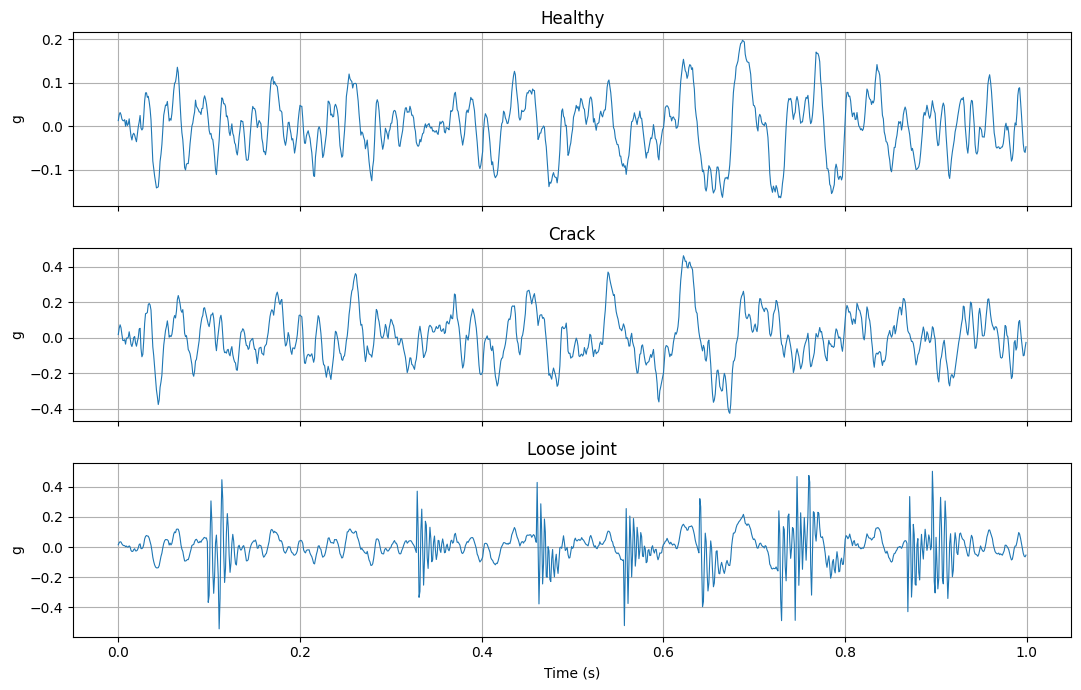

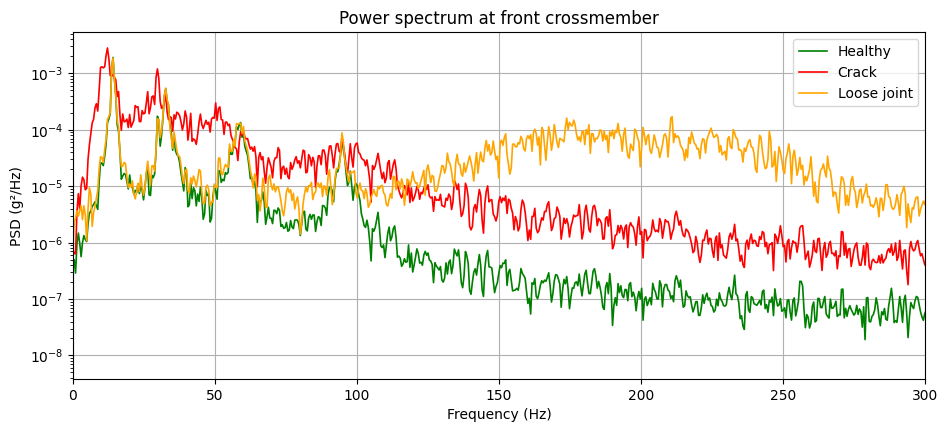

33 features per window
Dataset: (600, 33) | classes: [200 200 200]
RMS thresholds (g): [0.076  0.076  0.0756]
Healthy     : alarm rate =   1.0%
Crack       : alarm rate = 100.0%
Loose joint : alarm rate =  96.0%
False alarms on unseen healthy data: 8.3%
Detection rate - Crack       : 87.5%
Detection rate - Loose joint : 100.0%


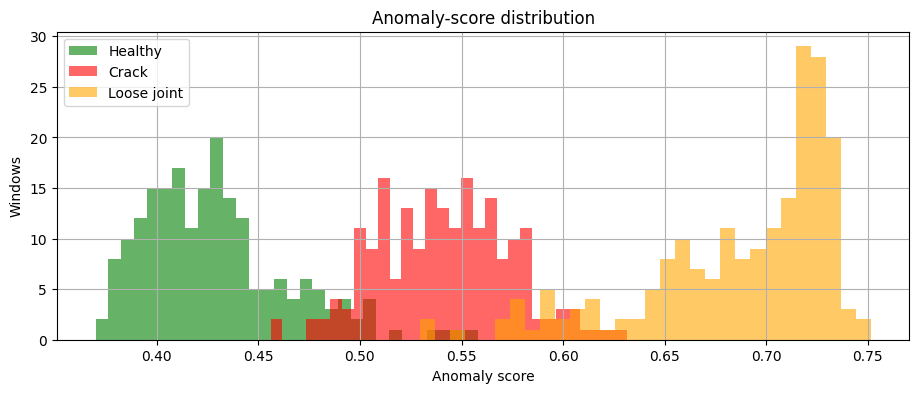

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        60
       Crack       1.00      1.00      1.00        60
 Loose joint       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



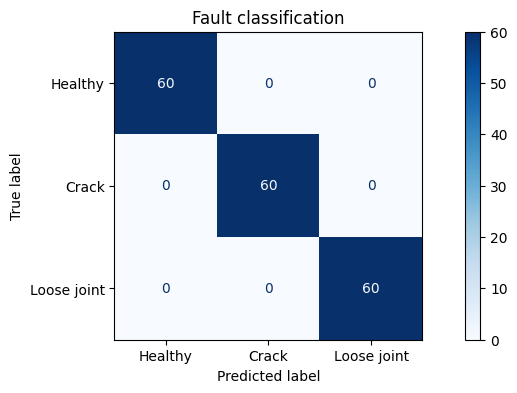

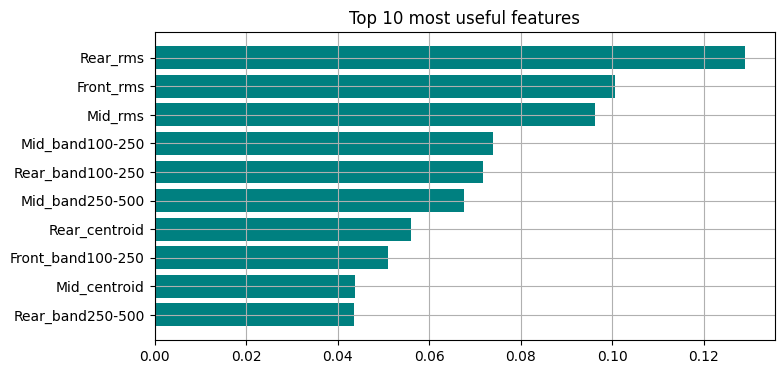

Localisation accuracy: 97%  (58/60)


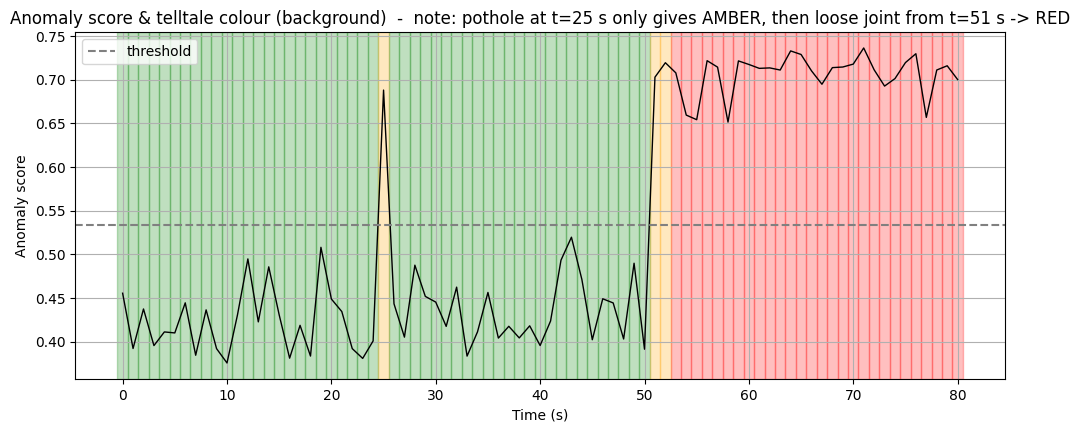

First RED at t = 53 s (loose joint began at t = 51 s)


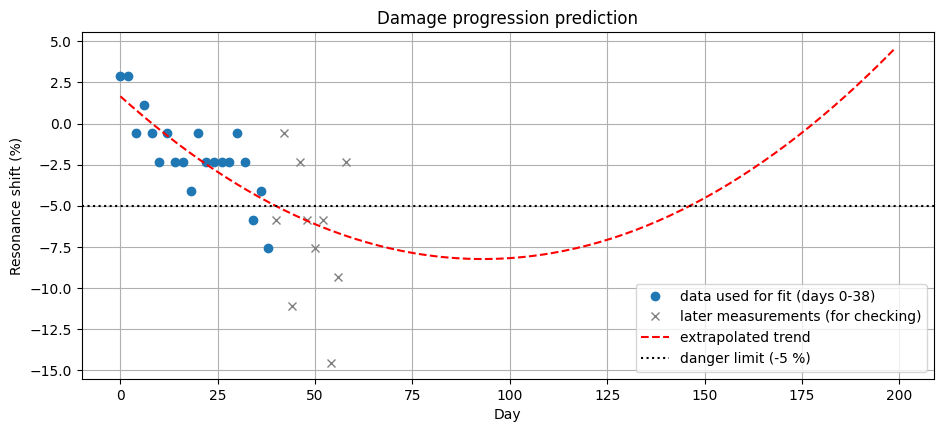

Predicted to cross the danger limit around day 40


Output()

RMS limits (g): [0.076 0.076 0.076] | kurtosis limits: [1.34 1.18 1.46]
Front crossmember  RMS=0.090 kurt=1.00 -> ABNORMAL
Mid side-rail      RMS=0.050 kurt=0.00 -> ok
Rear axle mount    RMS=0.050 kurt=0.00 -> ok
TELLTALE: 🔴 RED - inspect chassis
 SMART CHASSIS VIBRATION ANALYSIS - RESULTS
 Threshold detector  : Crack 100% | Loose 96% | False alarm 1%
 Isolation Forest    : Crack 88% | Loose 100% | False alarm 8%
 Fault classifier    : accuracy 100.0%
 Localisation        : 97%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

FS = 1000                      # sampling rate (Hz) - typical for MCU + accelerometer
SENSORS = ["Front crossmember", "Mid side-rail", "Rear axle mount"]
CLASSES = ["Healthy", "Crack", "Loose joint"]
print("Sampling rate:", FS, "Hz | Sensors:", SENSORS)

# (frequency Hz, damping ratio, amplitude) of chassis modes in healthy state
MODES = [(14, 0.030, 1.0), (33, 0.030, 0.7), (58, 0.025, 0.5), (95, 0.020, 0.3)]

def simulate(condition="Healthy", severity=0.0, fault_sensor=0, dur=1.0, seed=None):
    """Return array (n_sensors, n_samples) of acceleration in g.
    condition: 'Healthy' | 'Crack' | 'Loose joint'; severity in [0,1]."""
    r = np.random.default_rng(seed)
    n = int(dur * FS); t = np.arange(n) / FS
    out = np.zeros((len(SENSORS), n))
    for s in range(len(SENSORS)):
        local = 1.0 if s == fault_sensor else 0.35     # fault is felt most at nearest sensor
        x = np.zeros(n)
        for i, (f, z, a) in enumerate(MODES):
            f_eff, z_eff, a_eff = f, z, a
            if condition == "Crack":
                if i < 3:                                # stiffness loss -> frequency drop
                    f_eff = f * (1 - 0.15 * severity * local)
                z_eff = z * (1 + 4 * severity * local)   # more damping / friction at crack faces
                a_eff = a * (1 + 1.2 * severity * local)
            b, a_ = signal.iirpeak(f_eff, Q=1 / (2 * z_eff), fs=FS)
            m = signal.lfilter(b, a_, r.normal(size=n))
            x += a_eff * m / (np.std(m) + 1e-9)
        x *= 0.05                                        # scale to ~0.05 g RMS
        # road noise (low freq) + engine order (30 Hz & 60 Hz)
        rb, ra = signal.butter(2, 40, fs=FS)
        x += 0.02 * signal.lfilter(rb, ra, r.normal(size=n))
        x += 0.02 * np.sin(2*np.pi*30*t + r.uniform(0, 6.28)) + 0.008*np.sin(2*np.pi*60*t + r.uniform(0, 6.28))
        # loose joint rattle: random impacts with ringing at 150-250 Hz
        if condition == "Loose joint":
            rate = (2 + 10 * severity)                   # impacts per second
            for _ in range(r.poisson(rate * dur * local)):
                k = r.integers(0, n - 60)
                tt = np.arange(60) / FS
                fr = r.uniform(150, 250)
                x[k:k+60] += (0.15 + 0.35*severity) * r.choice([-1, 1]) * np.exp(-tt/0.012) * np.sin(2*np.pi*fr*tt)
        x += r.normal(0, 0.004, n)                       # sensor noise
        out[s] = x
    return out

# Quick look: the three conditions on the front sensor
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for a, (c, sv) in zip(ax, [("Healthy", 0), ("Crack", 0.9), ("Loose joint", 0.9)]):
    sig = simulate(c, sv, fault_sensor=0, dur=1.0, seed=1)[0]
    a.plot(np.arange(len(sig))/FS, sig, lw=0.8); a.set_ylabel("g"); a.set_title(c)
ax[-1].set_xlabel("Time (s)"); plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 4.5))
for c, sv, col in [("Healthy", 0, "green"), ("Crack", 0.9, "red"), ("Loose joint", 0.9, "orange")]:
    sig = simulate(c, sv, fault_sensor=0, dur=8, seed=3)[0]
    f, p = signal.welch(sig, FS, nperseg=2048)
    plt.semilogy(f, p, label=c, color=col, lw=1.2)
plt.xlim(0, 300); plt.xlabel("Frequency (Hz)"); plt.ylabel("PSD (g²/Hz)")
plt.title("Power spectrum at front crossmember"); plt.legend(); plt.show()

BANDS = [(0, 20), (20, 50), (50, 100), (100, 250), (250, 500)]
FEAT_NAMES = ["rms", "peak", "crest", "kurtosis", "dom_freq", "centroid"] + [f"band{lo}-{hi}" for lo, hi in BANDS]

def features_one(x):
    x = x - np.mean(x)
    rms = np.sqrt(np.mean(x**2)); pk = np.max(np.abs(x))
    f, p = signal.welch(x, FS, nperseg=256)
    tot = p.sum() + 1e-12
    bands = [p[(f >= lo) & (f < hi)].sum() / tot for lo, hi in BANDS]
    return [rms, pk, pk/rms, stats.kurtosis(x), f[np.argmax(p)], (f*p).sum()/tot] + bands

def features(window):                       # window: (n_sensors, n_samples)
    return np.concatenate([features_one(ch) for ch in window])

ALL_FEATS = [f"{s.split()[0]}_{n}" for s in SENSORS for n in FEAT_NAMES]
print(len(ALL_FEATS), "features per window")


def make_dataset(n_per_class=200, seed0=0):
    X, y, sev = [], [], []
    k = seed0
    for label, cond in enumerate(CLASSES):
        for _ in range(n_per_class):
            s = 0.0 if cond == "Healthy" else rng.uniform(0.3, 1.0)
            fs_ = rng.integers(0, len(SENSORS))
            X.append(features(simulate(cond, s, fs_, dur=1.0, seed=k))); y.append(label); sev.append(s); k += 1
    return np.array(X), np.array(y), np.array(sev)

X, y, sev = make_dataset(200)
print("Dataset:", X.shape, "| classes:", np.bincount(y))

rms_idx = [i for i, n in enumerate(ALL_FEATS) if n.endswith("_rms")]
kur_idx = [i for i, n in enumerate(ALL_FEATS) if n.endswith("_kurtosis")]
healthy = X[y == 0]
thr_rms = healthy[:, rms_idx].mean(0) + 4 * healthy[:, rms_idx].std(0)
thr_kur = healthy[:, kur_idx].mean(0) + 4 * healthy[:, kur_idx].std(0)
print("RMS thresholds (g):", np.round(thr_rms, 4))

def threshold_alarm(feat_row):
    return bool(np.any(feat_row[rms_idx] > thr_rms) or np.any(feat_row[kur_idx] > thr_kur))

alarm = np.array([threshold_alarm(r) for r in X])
for i, c in enumerate(CLASSES):
    print(f"{c:12s}: alarm rate = {alarm[y == i].mean()*100:5.1f}%")


Xh_train, Xh_test = train_test_split(X[y == 0], test_size=0.3, random_state=0)
scaler_a = StandardScaler().fit(Xh_train)
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=0).fit(scaler_a.transform(Xh_train))

def anomaly_score(Xrows):                   # higher = more abnormal
    return -iso.score_samples(scaler_a.transform(Xrows))

flag_h = iso.predict(scaler_a.transform(Xh_test)) == -1
print(f"False alarms on unseen healthy data: {flag_h.mean()*100:.1f}%")
for i in (1, 2):
    fl = iso.predict(scaler_a.transform(X[y == i])) == -1
    print(f"Detection rate - {CLASSES[i]:12s}: {fl.mean()*100:.1f}%")

plt.figure(figsize=(11, 4))
for i, col in enumerate(["green", "red", "orange"]):
    plt.hist(anomaly_score(X[y == i]), bins=30, alpha=0.6, color=col, label=CLASSES[i])
plt.xlabel("Anomaly score"); plt.ylabel("Windows"); plt.title("Anomaly-score distribution"); plt.legend(); plt.show()


Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)
clf = RandomForestClassifier(n_estimators=300, random_state=1).fit(Xtr, ytr)
pred = clf.predict(Xte)
print(classification_report(yte, pred, target_names=CLASSES))
ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=CLASSES, cmap="Blues")
plt.grid(False); plt.title("Fault classification"); plt.show()

imp = clf.feature_importances_; top = np.argsort(imp)[-10:]
plt.figure(figsize=(8, 4)); plt.barh([ALL_FEATS[i] for i in top], imp[top], color="teal")
plt.title("Top 10 most useful features"); plt.show()

def locate(feat_row):
    """Sensor whose RMS deviates most from the healthy baseline (in sigmas)."""
    z = (feat_row[rms_idx] - healthy[:, rms_idx].mean(0)) / healthy[:, rms_idx].std(0)
    return int(np.argmax(np.abs(z)))

correct = total = 0
for _ in range(60):
    loc = rng.integers(0, 3)
    w = simulate(rng.choice(["Crack", "Loose joint"]), rng.uniform(0.6, 1.0), loc, seed=int(rng.integers(1e9)))
    correct += locate(features(w)) == loc; total += 1
print(f"Localisation accuracy: {correct/total*100:.0f}%  ({correct}/{total})")

def telltale_state(consec):
    return "GREEN" if consec == 0 else ("AMBER" if consec < 3 else "RED")

timeline, cond_log = [], []
for k in range(25): timeline.append(simulate("Healthy", 0, 0, seed=5000+k)); cond_log.append("Healthy")
pothole = simulate("Healthy", 0, 0, seed=6000); pothole[:, 400:430] += 0.5 * np.exp(-np.arange(30)/8)   # one big bump
timeline.append(pothole); cond_log.append("Pothole")
for k in range(25): timeline.append(simulate("Healthy", 0, 0, seed=7000+k)); cond_log.append("Healthy")
for k in range(30): timeline.append(simulate("Loose joint", 0.7, 1, seed=8000+k)); cond_log.append("Loose joint")

scores = np.array([anomaly_score(features(w)[None])[0] for w in timeline])
thr_score = np.percentile(anomaly_score(Xh_train), 99)
consec, states = 0, []
for s in scores:
    consec = consec + 1 if s > thr_score else 0
    states.append(telltale_state(consec))

colors = {"GREEN": "green", "AMBER": "orange", "RED": "red"}
plt.figure(figsize=(12, 4.5))
plt.plot(scores, color="k", lw=1); plt.axhline(thr_score, color="gray", ls="--", label="threshold")
for i, st in enumerate(states): plt.axvspan(i-0.5, i+0.5, color=colors[st], alpha=0.25)
plt.xlabel("Time (s)"); plt.ylabel("Anomaly score")
plt.title("Anomaly score & telltale colour (background)  -  note: pothole at t=25 s only gives AMBER, then loose joint from t=51 s -> RED")
plt.legend(); plt.show()
print("First RED at t =", states.index("RED"), "s (loose joint began at t = 51 s)")

days = np.arange(0, 60, 2)
severity_curve = 0.6 * (days / 60) ** 1.5          # crack grows slowly, then faster
f0, meas = MODES[0][0], []
for d, sv in zip(days, severity_curve):
    sig = simulate("Crack", sv, fault_sensor=0, dur=10, seed=int(d)+100)[0]
    f, p = signal.welch(sig, FS, nperseg=4096)
    band = (f > 8) & (f < 20)
    meas.append(f[band][np.argmax(p[band])])
meas = np.array(meas); shift_pct = (meas - f0) / f0 * 100

# fit a quadratic trend to the last 15 points -> extrapolate
fit_days = days[:20]; coef = np.polyfit(fit_days, shift_pct[:20], 2)   # use only the first 40 days of data
future = np.arange(days[0], 200)
trend = np.polyval(coef, future)
limit = -5.0
cross = future[np.argmax(trend < limit)] if np.any(trend < limit) else None

plt.figure(figsize=(11, 4.5))
plt.plot(days[:20], shift_pct[:20], "o", label="data used for fit (days 0-38)")
plt.plot(days[20:], shift_pct[20:], "x", color="gray", label="later measurements (for checking)")
plt.plot(future, trend, "r--", label="extrapolated trend")
plt.axhline(limit, color="k", ls=":", label="danger limit (-5 %)")
plt.xlabel("Day"); plt.ylabel("Resonance shift (%)"); plt.title("Damage progression prediction"); plt.legend(); plt.show()
print(f"Predicted to cross the danger limit around day {cross}" if cross else "Limit not reached in forecast window")

import ipywidgets as widgets
from IPython.display import display

def run_test(condition="Healthy", severity=0.5, location="Front crossmember", pothole=False, show_plots=True):
    loc = SENSORS.index(location)
    sev = 0.0 if condition == "Healthy" else severity
    consec = 0
    for k in range(3):                                       # 3 consecutive 1-second windows (persistence rule)
        w = simulate(condition, sev, loc, dur=1.0, seed=int(rng.integers(1e9)))
        if pothole and k == 0:                               # a single road shock, only in the first second
            w[:, 400:430] += 0.5 * np.exp(-np.arange(30) / 8)
        fr = features(w)
        score = anomaly_score(fr[None])[0]
        consec = consec + 1 if score > thr_score else 0
    proba = clf.predict_proba(fr[None])[0]
    pred_cls = CLASSES[int(np.argmax(proba))]
    state = telltale_state(consec)
    emoji = {"RED": "\U0001F534", "AMBER": "\U0001F7E1", "GREEN": "\U0001F7E2"}[state]
    print(f"TELLTALE      : {emoji} {state}   (abnormal windows in a row: {consec}/3)")
    print(f"Anomaly score : {score:.3f}  (threshold {thr_score:.3f})")
    print(f"Fault type    : {pred_cls}   (" + ", ".join(f"{c}: {p*100:.0f}%" for c, p in zip(CLASSES, proba)) + ")")
    if consec > 0: print(f"Likely location: {SENSORS[locate(fr)]}")
    if show_plots:
        fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
        for i, sname in enumerate(SENSORS):
            ax[0].plot(np.arange(w.shape[1]) / FS, w[i] + i * 0.6, lw=0.7, label=sname)
        ax[0].set_title("Accelerometer signals (offset for clarity)"); ax[0].set_xlabel("Time (s)"); ax[0].legend(fontsize=7)
        for i, sname in enumerate(SENSORS):
            f, p = signal.welch(w[i], FS, nperseg=256); ax[1].semilogy(f, p, label=sname)
        ax[1].set_xlim(0, 300); ax[1].set_title("Spectrum"); ax[1].set_xlabel("Hz"); ax[1].legend(fontsize=7)
        plt.tight_layout(); plt.show()

w_cond = widgets.Dropdown(options=CLASSES, value="Crack", description="Condition")
w_sev  = widgets.FloatSlider(value=0.6, min=0, max=1, step=0.05, description="Severity")
w_loc  = widgets.Dropdown(options=SENSORS, description="Fault at")
w_pot  = widgets.Checkbox(value=False, description="Add pothole hit")
ui = widgets.VBox([w_cond, w_sev, w_loc, w_pot])
out = widgets.interactive_output(run_test, {"condition": w_cond, "severity": w_sev, "location": w_loc, "pothole": w_pot})
display(ui, out)

def manual_check(rms_front, rms_mid, rms_rear, kurt_front=0.0, kurt_mid=0.0, kurt_rear=0.0):
    rms = np.array([rms_front, rms_mid, rms_rear]); kur = np.array([kurt_front, kurt_mid, kurt_rear])
    bad_rms = rms > thr_rms; bad_kur = kur > thr_kur
    print("RMS limits (g):", np.round(thr_rms, 3), "| kurtosis limits:", np.round(thr_kur, 2))
    for s, r_, k_, b1, b2 in zip(SENSORS, rms, kur, bad_rms, bad_kur):
        print(f"{s:18s} RMS={r_:.3f} kurt={k_:.2f} -> {'ABNORMAL' if (b1 or b2) else 'ok'}")
    print("TELLTALE:", "\U0001F534 RED - inspect chassis" if (bad_rms.any() or bad_kur.any()) else "\U0001F7E2 GREEN - normal")

manual_check(rms_front=0.09, rms_mid=0.05, rms_rear=0.05, kurt_front=1.0)   # <- change these numbers and re-run

print("=" * 55)
print(" SMART CHASSIS VIBRATION ANALYSIS - RESULTS")
print("=" * 55)
print(f" Threshold detector  : Crack {alarm[y==1].mean()*100:.0f}% | Loose {alarm[y==2].mean()*100:.0f}% | False alarm {alarm[y==0].mean()*100:.0f}%")
print(f" Isolation Forest    : Crack {(iso.predict(scaler_a.transform(X[y==1]))==-1).mean()*100:.0f}% | Loose {(iso.predict(scaler_a.transform(X[y==2]))==-1).mean()*100:.0f}% | False alarm {flag_h.mean()*100:.0f}%")
print(f" Fault classifier    : accuracy {(pred==yte).mean()*100:.1f}%")
print(f" Localisation        : {correct/total*100:.0f}%")
print("=" * 55)

